# 第 12 章 · 手写数字扩散过程代码实验

本页用真实手写数字数据看扩散任务的直觉：前向过程把数字变成噪声，反向过程要逐步恢复可辨认的数字结构。

[章节网页](../ch12.html)

## 运行内容

- 加载手写数字数据
- 绘制前向加噪
- 展示去噪对比

## 0. 手写数字样本

先选出同一类数字的多个样本。干净图像用于对照，后面的噪声图像和去噪图像都要和它比较。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 从手写数字数据中选出一个 8x8 样本。
digits = load_digits()
digit_label = 3
digit_indices = np.where(digits.target == digit_label)[0]
clean_digit = digits.images[digit_indices[4]] / 16.0

display(pd.DataFrame(clean_digit).round(2))
print("样本数量:", len(digit_indices), "目标数字:", digit_label)

,0,1,2,3,4,5,6,7
0,0.0,0.06,0.62,0.94,0.69,0.06,0.00,0.0
1,0.0,0.19,0.50,0.50,0.69,0.75,0.00,0.0
2,0.0,0.00,0.00,0.31,0.88,0.94,0.06,0.0
3,0.0,0.00,0.00,0.69,0.94,0.12,0.00,0.0
4,0.0,0.00,0.00,0.25,0.94,0.12,0.00,0.0
5,0.0,0.00,0.00,0.00,0.75,0.62,0.00,0.0
6,0.0,0.00,0.19,0.25,0.62,1.00,0.06,0.0
7,0.0,0.00,0.81,1.00,0.94,0.62,0.00,0.0


样本数量: 183 目标数字: 3


## 1. 加噪与去噪

第一行展示噪声增强后数字如何变模糊；第二行比较干净图、噪声图、同类原型和去噪结果。

In [3]:
# 前向加噪：同一个数字在不同 t 下逐渐变得更难辨认。
rng = np.random.default_rng(11)
digit_noise = rng.normal(size=clean_digit.shape)
digit_steps = [0.0, 0.25, 0.50, 0.75]
digit_forward = []
for level in digit_steps:
    noisy = np.sqrt(1 - level) * clean_digit + np.sqrt(level) * digit_noise
    digit_forward.append(noisy)

digit_forward_df = pd.DataFrame({
    "噪声强度": digit_steps,
    "MSE": [round(mean_squared_error(clean_digit, img), 4) for img in digit_forward],
})
display(digit_forward_df)

,噪声强度,MSE
0,0.00,0.0000
1,0.25,0.1965
2,0.50,0.4103
3,0.75,0.6520


In [4]:
# 训练一个小型去噪器，把带噪数字恢复成干净数字。
train_rng = np.random.default_rng(12)
all_clean_digits = digits.data / 16.0
all_noisy_digits = np.clip(
    all_clean_digits + train_rng.normal(0, 0.45, all_clean_digits.shape),
    0,
    1,
)
digit_denoiser = MLPRegressor(hidden_layer_sizes=(96,), max_iter=180, random_state=12)
digit_denoiser.fit(all_noisy_digits, all_clean_digits)

noisy_digit = np.clip(digit_forward[-1], 0, 1)
denoised_digit = np.clip(digit_denoiser.predict(noisy_digit.reshape(1, -1))[0].reshape(8, 8), 0, 1)
digits_summary = pd.DataFrame(
    [
        {"图像": "noisy", "相对clean的MSE": mean_squared_error(clean_digit, noisy_digit)},
        {"图像": "denoised", "相对clean的MSE": mean_squared_error(clean_digit, denoised_digit)},
    ]
).round(4)
display(digits_summary)

,图像,相对clean的MSE
0,noisy,0.2374
1,denoised,0.0917


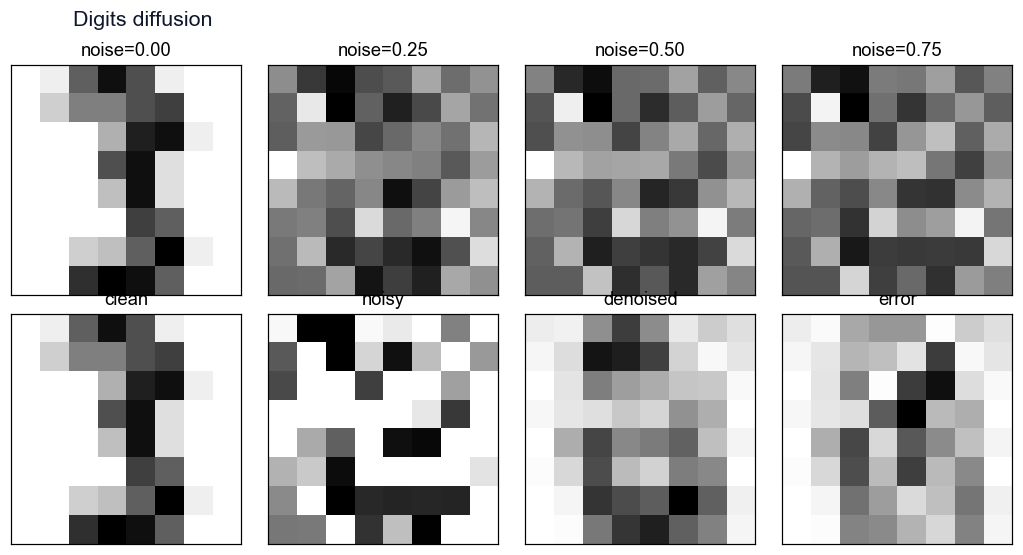

In [5]:
# 绘制前向加噪和去噪对比。
fig, axes = plt.subplots(2, 4, figsize=(9.5, 5.1))
for ax, img, level in zip(axes[0], digit_forward, digit_steps):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(f"noise={level:.2f}", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
for ax, img, title in zip(axes[1], [clean_digit, noisy_digit, denoised_digit, np.abs(clean_digit - denoised_digit)], ["clean", "noisy", "denoised", "error"]):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Digits diffusion", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()